In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("=== Basic Info ===")
df.info()

print("\n=== Descriptive Statistics ===")
df.describe()

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== Descriptive Statistics ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

             Missing Count  Missing %
PassengerId              0       0.00
Survived                 0       0.00
Pclass                   0       0.00
Name                     0       0.00
Sex                      0       0.00
Age                    177      19.87
SibSp                    0       0.00
Parch                    0       0.00
Ticket                   0       0.00
Fare                     0       0.00
Cabin                  687      77.10
Embarked                 2       0.22


/tmp/ipykernel_3189/3950620224.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', ax=axes[0,0], palette='Set2')
/tmp/ipykernel_3189/3950620224.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['Died', 'Survived'])
/tmp/ipykernel_3189/3950620224.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[0,1], palette='Set2')
/tmp/ipykernel_3189/3950620224.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=Fals

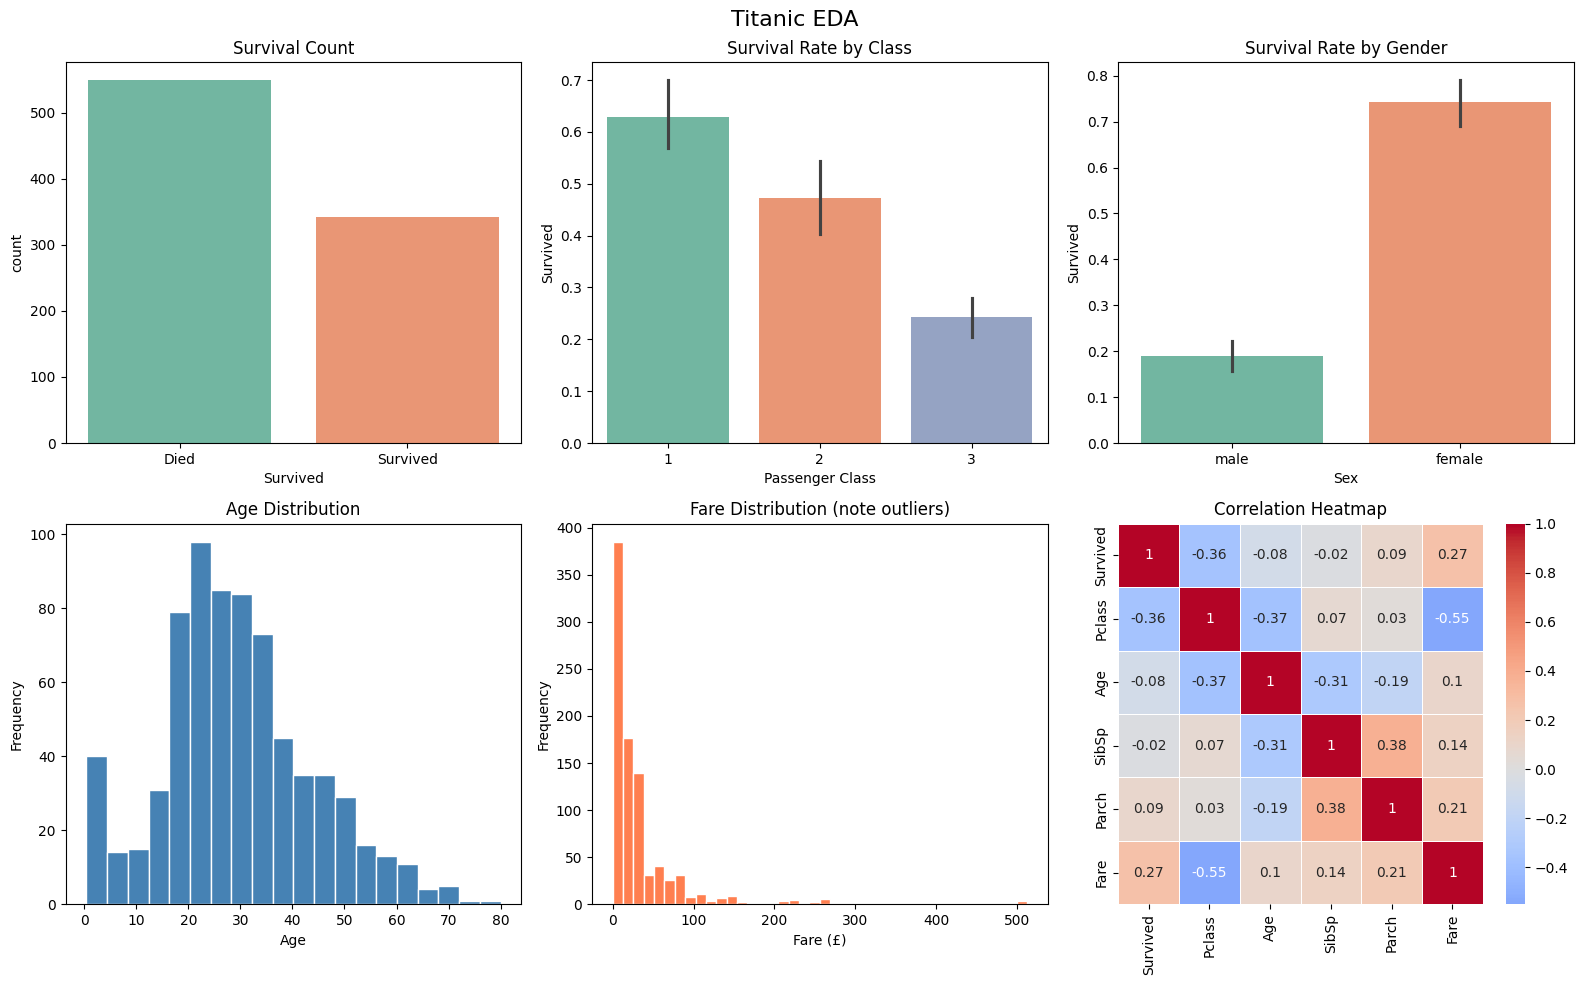

In [ ]:
# ── Cell 6: Charts ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Titanic EDA", fontsize=16)

# 1. Survival count
sns.countplot(data=df, x='Survived', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Survival Count')
axes[0,0].set_xticklabels(['Died', 'Survived'])

# 2. Survival by class
sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Survival Rate by Class')
axes[0,1].set_xlabel('Passenger Class')

# 3. Survival by gender
sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0,2], palette='Set2')
axes[0,2].set_title('Survival Rate by Gender')

# 4. Age distribution
df['Age'].dropna().plot(kind='hist', bins=20, ax=axes[1,0], color='steelblue', edgecolor='white')
axes[1,0].set_title('Age Distribution')
axes[1,0].set_xlabel('Age')

# 5. Fare distribution (shows outliers)
df['Fare'].plot(kind='hist', bins=40, ax=axes[1,1], color='coral', edgecolor='white')
axes[1,1].set_title('Fare Distribution (note outliers)')
axes[1,1].set_xlabel('Fare (£)')

# 6. Correlation heatmap
numeric_cols = df[['Survived','Pclass','Age','SibSp','Parch','Fare']].dropna()
sns.heatmap(numeric_cols.corr().round(2), annot=True, cmap='coolwarm',
            ax=axes[1,2], center=0, linewidths=0.5)
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [ ]:
for col in ['Age', 'Fare']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers  |  range [{lower:.1f}, {upper:.1f}]")

Age: 11 outliers  |  range [-6.7, 64.8]
Fare: 116 outliers  |  range [-26.7, 65.6]


In [ ]:
print("""
KEY FINDINGS
────────────
1. Survival rate:   38.4% overall
2. Gender effect:   Women survived at 74% vs men at 19%
3. Class effect:    1st class 63%, 2nd 47%, 3rd 24%
4. Age:             Mean 29.7 yrs | 177 values missing (19.9%)
5. Fare outliers:   Max £512 vs median £14 — strong right skew
6. Correlation:     Pclass negatively correlated with Fare (-0.55)
""")



KEY FINDINGS
────────────
1. Survival rate:   38.4% overall
2. Gender effect:   Women survived at 74% vs men at 19%
3. Class effect:    1st class 63%, 2nd 47%, 3rd 24%
4. Age:             Mean 29.7 yrs | 177 values missing (19.9%)
5. Fare outliers:   Max £512 vs median £14 — strong right skew
6. Correlation:     Pclass negatively correlated with Fare (-0.55)

